Knowing that x-ray images contain patterns specific to certain diseases, we can try to prelearn our model with those patterns in the appropriate convolution kernels.

In [2]:

import os
import shutil
import kagglehub

# Download dataset
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
# Move dataset to parent directory
shutil.move(os.path.join(path, 'COVID-19_Radiography_Dataset'), "..")
print("Covid-19 Radiography Dataset downloaded and moved to parent directory.")

100%|██████████| 778M/778M [00:35<00:00, 23.1MB/s]

Extracting files...


Covid-19 Radiography Dataset downloaded and moved to parent directory.


In [1]:
# List available GPUs
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ TensorFlow is using a GPU:")
    for gpu in gpus:
        print("  -", gpu)
else:
    print("❌ No GPU detected. TensorFlow is using the CPU.")

✅ TensorFlow is using a GPU:
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Conv2D

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reporting t
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.metrics import classification_report_imbalanced

# Imports for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [32]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import helper
import importlib
importlib.reload(helper)

<module 'helper' from '/content/helper.py'>

In [5]:
# Read in the images
train_ds, val_ds, class_names = helper.read_only_xray_images(input_shape=(256,256))

Created empty directory: /tmp_920997340
Made directory: /tmp_920997340/Viral Pneumonia/
Moved /COVID-19_Radiography_Dataset/Viral Pneumonia/masks to /tmp_920997340/Viral Pneumonia/masks
Made directory: /tmp_920997340/Lung_Opacity/
Moved /COVID-19_Radiography_Dataset/Lung_Opacity/masks to /tmp_920997340/Lung_Opacity/masks
Made directory: /tmp_920997340/COVID/
Moved /COVID-19_Radiography_Dataset/COVID/masks to /tmp_920997340/COVID/masks
Made directory: /tmp_920997340/Normal/
Moved /COVID-19_Radiography_Dataset/Normal/masks to /tmp_920997340/Normal/masks
Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Using 4233 files for validation.
Found classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train dataset batch: (32, 256, 256, 3) (32,)
Labels [1 1 2 2 2 2 1 2 2 2 0 2 1 2 2 2 0 2 0 2 0 1 1 1 2 1 2 1 2 2 0 2]
Validation dataset batch: (32, 256, 256, 3) (32,)
Labels [1 2 1 1 0 2 2 3 1 2 0 2 2 2 1 2 1 2 3 2 2 2 0 2 2 0 1 1 3 2 0 1]
Moved /tmp_920997340/Vir

In [6]:
# Convert grayscale (256,256,3) -> (256,256,1) in order to make it simpler for our model
# Function to ensure images are in (256,256,1) format
def to_grayscale(image, label):
    image = tf.image.rgb_to_grayscale(image) if image.shape[-1] == 3 else image  # Convert if needed
    return image, label

train_ds = train_ds.map(to_grayscale)
val_ds = val_ds.map(to_grayscale)

In [7]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())

# Let's check compatible input format for our model
for images, labels in train_ds.take(1):
    print('Batch shape:', images.shape, labels.shape)
    # Show some sample image shapes and according labels (should be shuffled!)
    for image, label in zip(images.numpy(),labels.numpy()):
        print(image.shape, label)

Number of batch in train_ds: 530
Number of batch in val_ds: 133
Batch shape: (32, 256, 256, 1) (32,)
(256, 256, 1) 1
(256, 256, 1) 2
(256, 256, 1) 2
(256, 256, 1) 3
(256, 256, 1) 1
(256, 256, 1) 2
(256, 256, 1) 0
(256, 256, 1) 1
(256, 256, 1) 2
(256, 256, 1) 0
(256, 256, 1) 2
(256, 256, 1) 2
(256, 256, 1) 1
(256, 256, 1) 2
(256, 256, 1) 1
(256, 256, 1) 3
(256, 256, 1) 2
(256, 256, 1) 2
(256, 256, 1) 2
(256, 256, 1) 2
(256, 256, 1) 1
(256, 256, 1) 0
(256, 256, 1) 0
(256, 256, 1) 1
(256, 256, 1) 1
(256, 256, 1) 0
(256, 256, 1) 1
(256, 256, 1) 1
(256, 256, 1) 1
(256, 256, 1) 1
(256, 256, 1) 0
(256, 256, 1) 0


In [8]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label])
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'Viral Pneumonia': 1048, 'Lung_Opacity': 4847, 'Normal': 8134, 'COVID': 2903}
Class Weights: {np.int32(3): 4.03912213740458, np.int32(1): 0.8733237053847741, np.int32(2): 0.5204081632653061, np.int32(0): 1.4581467447468137}


In [9]:
# This model name for saving and loading
model_name = 'fromscratch_' + str(len(class_names)) + '-classes.keras'

In [10]:
# Applied Callbacks
early_stopping = EarlyStopping(
                                patience=5, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 5 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min',
                                monitor='val_loss')

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=5, # If val_loss stagnates for 5 consecutive epochs based on the min_delta value
                                    min_delta=0.01,
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

Strategy for the First Convolutional Layer

Use medically relevant kernels:
* Sobel filters → Detect lung boundaries.
* Laplacian filters → Highlight nodules and opacities.
* Gabor filters → Capture texture changes (useful for pneumonia, fibrosis).
* Gaussian filters → Enhance image contrast.
- Randomly initialize remaining filters (if we don’t have 64 predefined kernels).
- Apply small noise and transformations to all filters to ensure diversity.

In [ ]:
# Let's create our specialized medical convolution layer
import cv2

# Function to create a Gabor filter
def gabor_kernel(ksize=3, sigma=1.0, theta=0, lambd=10.0, gamma=0.5, psi=0):
    return cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F)

# Define known kernels (3x3)
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)  # Edge detection
sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)  # Vertical edges
laplacian = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float32)  # Enhancing details
gaussian = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16  # Smoothing
gabor = gabor_kernel()  # Extracts textures

# Store the known filters in a list
known_filters = [sobel_x, sobel_y, laplacian, gaussian, gabor]

# Number of filters needed
total_filters = 64
known_filter_count = len(known_filters)
remaining_filters = total_filters - known_filter_count

# Initialize filter tensor (3,3,1,64)
filters = np.zeros((3, 3, 1, total_filters), dtype=np.float32)

# Assign known filters
for i, kernel in enumerate(known_filters):
    filters[:, :, 0, i] = kernel  # Each kernel occupies one filter slot

# Assign random filters for the remaining slots
for i in range(known_filter_count, total_filters):
    random_kernel = np.random.randn(3, 3) * 0.1  # Small random values
    random_kernel +=  known_filters[np.random.choice(known_filter_count)] # Base it on a known filter with noise
    filters[:, :, 0, i] = random_kernel

# Define the first convolutional layer with these filters
med_conv_layer = tf.keras.layers.Conv2D(
    filters=total_filters, kernel_size=(3,3), activation='relu',
    kernel_initializer=tf.keras.initializers.Constant(filters),
    padding="same"
)

In [ ]:
# Build a model with it
# Define the full CNN model
model = tf.keras.Sequential([
    Input(shape=(256, 256, 1)),  # X-ray grayscale input
    med_conv_layer,  # Predefined first convolution layer with 64 neurons
    MaxPooling2D((2,2)),  # Reduce feature map size
    Conv2D(128, (3,3), activation='relu'),  # Deeper learned features
    MaxPooling2D((2,2)),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(512, (3,3), activation='relu'),
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(class_names), activation='softmax')
])

In [ ]:
# Compile with first idea of appropriate parameters
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Print how it looks like
model.summary()

# Convert summary to DataFrame and display it (for copy and paste purposes)
df_summary = helper.model_summary_to_df(model)
display(df_summary)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 256, 256, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 63, 63, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 61, 61, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,206,852 (8.42 MB)

 Trainable params: 2,206,852 (8.42 MB)

 Non-trainable params: 0 (0.00 B)

,Layer Name (type),Output Shape,Param Count
0,conv2d (Conv2D),"(None, 256, 256, 64)",640
1,max_pooling2d (MaxPooling2D),"(None, 128, 128, 64)",0
2,conv2d_1 (Conv2D),"(None, 126, 126, 128)","73,856"
3,max_pooling2d_1 (MaxPooling2D),"(None, 63, 63, 128)",0
4,conv2d_2 (Conv2D),"(None, 61, 61, 256)","295,168"
5,max_pooling2d_2 (MaxPooling2D),"(None, 30, 30, 256)",0
6,conv2d_3 (Conv2D),"(None, 28, 28, 512)","1,180,160"
7,global_average_pooling2d,"(None, 512)",0
8,(GlobalAveragePooling2D),,
9,dense (Dense),"(None, 1024)","525,312"


In [ ]:
# Train it with the entire dataset (takes very long!)
history_model = model.fit(train_ds,
                          epochs=25,
                          validation_data=val_ds,
                          class_weight=class_weights_dict)#,
                          #callbacks=[early_stopping, reduce_learning_rate])

Epoch 1/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 89s 167ms/step - accuracy: 0.4609 - loss: 1.1289 - val_accuracy: 0.6093 - val_loss: 0.9028
Epoch 2/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 138s 161ms/step - accuracy: 0.6311 - loss: 0.7067 - val_accuracy: 0.6678 - val_loss: 0.7734
Epoch 3/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 142s 160ms/step - accuracy: 0.6828 - loss: 0.6254 - val_accuracy: 0.7092 - val_loss: 0.7379
Epoch 4/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 142s 161ms/step - accuracy: 0.6273 - loss: 0.7671 - val_accuracy: 0.6097 - val_loss: 0.8720
Epoch 5/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 96s 181ms/step - accuracy: 0.6793 - loss: 0.6365 - val_accuracy: 0.7408 - val_loss: 0.6578
Epoch 6/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 96s 181ms/step - accuracy: 0.7210 - loss: 0.5534 - val_accuracy: 0.7338 - val_loss: 0.6487
Epoch 7/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 96s 182ms/step - accuracy: 0.7378 - loss: 0.5129 - val_accuracy: 0.7614 - val_loss: 0.6002
Epoch 8/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 96s 182ms/step - accuracy: 0.7585 - loss

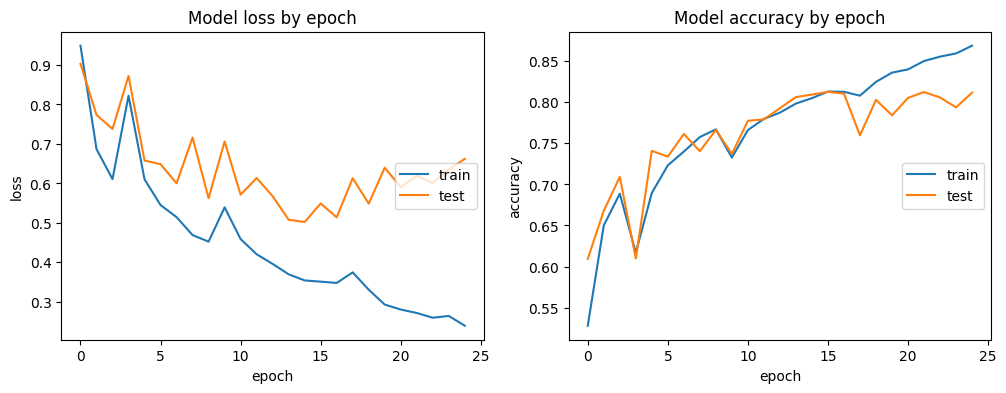

In [ ]:
helper.plot_learning_curve(history_model)

In [ ]:
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = helper.get_predictions_and_labels(model, val_ds)

,pre,rec,spe,f1,geo,iba,sup
COVID,0.899725,0.918654,0.979261,0.909091,0.948473,0.894150,713.000000
Lung_Opacity,0.728429,0.688412,0.902542,0.707855,0.788239,0.608017,1165.000000
Normal,0.811881,0.836735,0.816552,0.824121,0.826582,0.684616,2058.000000
Viral Pneumonia,0.908127,0.865320,0.993394,0.886207,0.927148,0.848595,297.000000
avg_pre,0.810463,0.810463,0.810463,0.810463,0.810463,0.810463,0.810463
avg_rec,0.811717,0.811717,0.811717,0.811717,0.811717,0.811717,0.811717
avg_spe,0.880032,0.880032,0.880032,0.880032,0.880032,0.880032,0.880032
avg_f1,0.810791,0.810791,0.810791,0.810791,0.810791,0.810791,0.810791
avg_geo,0.843616,0.843616,0.843616,0.843616,0.843616,0.843616,0.843616
avg_iba,0.710333,0.710333,0.710333,0.710333,0.710333,0.710333,0.710333


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,655,24,31,3
Lung_Opacity,28,802,334,1
Normal,41,273,1722,22
Viral Pneumonia,4,2,34,257


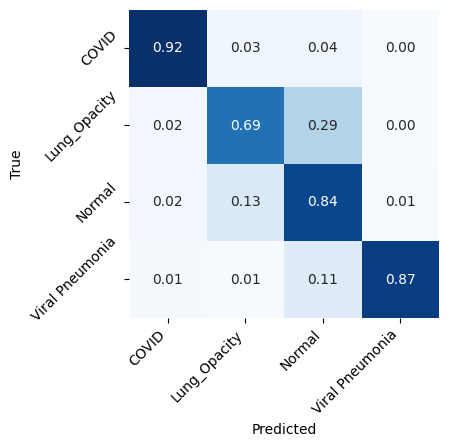

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              655            24      31                3
 Lung_Opacity        28           802     334                1
 Normal              41           273    1722               22
 Viral Pneumonia      4             2      34              257,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.899725     0.918654     0.979261     0.909091   
 Lung_Opacity        0.728429     0.688412     0.902542     0.707855   
 Normal              0.811881     0.836735     0.816552     0.824121   
 Viral Pneumonia     0.908127     0.865320     0.993394     0.886207   
 avg_pre             0.810463     0.810463     0.810463     0.810463   
 avg_rec             0.811717     0.811717     0.811717     0.811717   
 avg_spe             0.880032     0.880032     0.880032     0.880032   
 avg_f1              0.810791     0.810791     0.810791     0.810791   

In [ ]:
helper.report_model_performance(y_true, y_pred, class_names)
# not too bad

In [13]:
# Run another 25 epochs and train even further since we still converge,
# this time with reduced learning rate
history_model_2 = model.fit(train_ds.shuffle(1000),
                          epochs=25,
                          validation_data=val_ds,
                          class_weight=class_weights_dict,
                          callbacks=[reduce_learning_rate])

Epoch 1/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 71s 122ms/step - accuracy: 0.8783 - loss: 0.2251 - val_accuracy: 0.7794 - val_loss: 0.5933 - learning_rate: 0.0010
Epoch 2/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 56s 95ms/step - accuracy: 0.8865 - loss: 0.2085 - val_accuracy: 0.7931 - val_loss: 0.7080 - learning_rate: 0.0010
Epoch 3/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 56s 95ms/step - accuracy: 0.9011 - loss: 0.1852 - val_accuracy: 0.7905 - val_loss: 0.7439 - learning_rate: 0.0010
Epoch 4/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 56s 95ms/step - accuracy: 0.9095 - loss: 0.1674 - val_accuracy: 0.7928 - val_loss: 0.6249 - learning_rate: 0.0010
Epoch 5/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 56s 95ms/step - accuracy: 0.8891 - loss: 0.2150 - val_accuracy: 0.7834 - val_loss: 0.6988 - learning_rate: 0.0010
Epoch 6/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9300 - loss: 0.1353
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
530/530 ━━━━━━━━━━━━━━━━━━━━ 56s 95ms/step - accuracy: 0.9300 - l

##### Evaluation

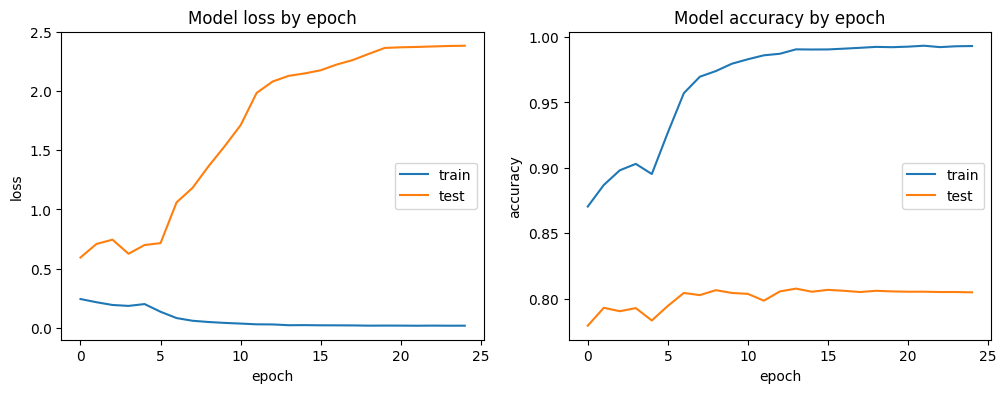

In [15]:
helper.plot_learning_curve(history_model_2)

In [19]:
# Save the model for potential later use
model.save(model_name)

In [11]:
# and load it again (to check proper saving)
from tensorflow import keras
model = keras.models.load_model(model_name)

In [16]:
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = helper.get_predictions_and_labels(model, val_ds)

,pre,rec,spe,f1,geo,iba,sup
COVID,0.935120,0.929874,0.986932,0.932489,0.957978,0.912486,713.000000
Lung_Opacity,0.705722,0.666953,0.894394,0.685790,0.772346,0.582951,1165.000000
Normal,0.796634,0.827988,0.800000,0.812009,0.813874,0.664245,2058.000000
Viral Pneumonia,0.926056,0.885522,0.994665,0.905336,0.938508,0.871184,297.000000
avg_pre,0.804020,0.804020,0.804020,0.804020,0.804020,0.804020,0.804020
avg_rec,0.804867,0.804867,0.804867,0.804867,0.804867,0.804867,0.804867
avg_spe,0.871124,0.871124,0.871124,0.871124,0.871124,0.871124,0.871124
avg_f1,0.804113,0.804113,0.804113,0.804113,0.804113,0.804113,0.804113
avg_geo,0.835462,0.835462,0.835462,0.835462,0.835462,0.835462,0.835462
avg_iba,0.698204,0.698204,0.698204,0.698204,0.698204,0.698204,0.698204


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,663,15,32,3
Lung_Opacity,15,777,371,2
Normal,30,308,1704,16
Viral Pneumonia,1,1,32,263


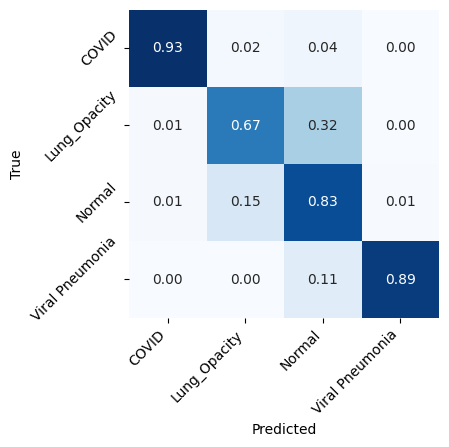

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              663            15      32                3
 Lung_Opacity        15           777     371                2
 Normal              30           308    1704               16
 Viral Pneumonia      1             1      32              263,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.935120     0.929874     0.986932     0.932489   
 Lung_Opacity        0.705722     0.666953     0.894394     0.685790   
 Normal              0.796634     0.827988     0.800000     0.812009   
 Viral Pneumonia     0.926056     0.885522     0.994665     0.905336   
 avg_pre             0.804020     0.804020     0.804020     0.804020   
 avg_rec             0.804867     0.804867     0.804867     0.804867   
 avg_spe             0.871124     0.871124     0.871124     0.871124   
 avg_f1              0.804113     0.804113     0.804113     0.804113   

In [17]:
helper.report_model_performance(y_true, y_pred, class_names)

# Conclusion: Our model predicts the 4 classes ...

##### Try some sample images

In [21]:
models = {'4-fromscratch': model}

In [29]:
model.input_shape[-1]

1

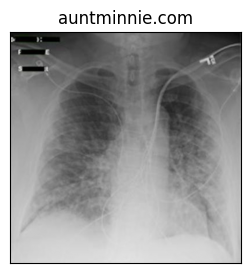

Resizing for model 4-fromscratch to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4-fromscratch,COVID,0.998,0.0,0.002,0.0


In [33]:
file_url = 'https://img.auntminnie.com/files/base/smg/all/image/2022/02/am.2022_02_02_00_09_3090_2022_02_03_CXR_covid_19_20220202005447.png?auto=format%2Ccompress&q=70&w=880'
helper.show_predict_image('auntminnie.com', helper.load_image_from_url(file_url), models)

# Nice, perfectly predicted

(612, 1536, 3)


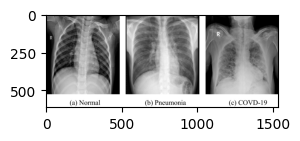

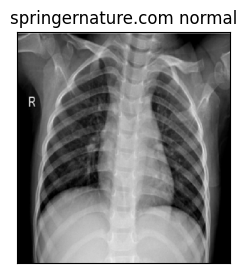

Resizing for model 4-fromscratch to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4-fromscratch,Normal,0.0,0.0,1.0,0.0


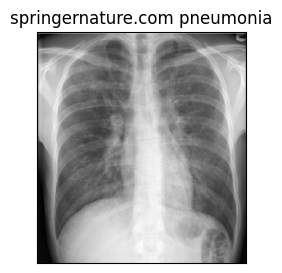

Resizing for model 4-fromscratch to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4-fromscratch,COVID,0.635,0.002,0.08,0.284


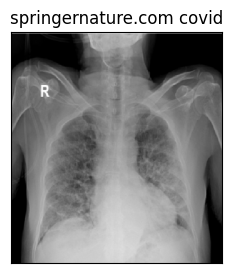

Resizing for model 4-fromscratch to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4-fromscratch,COVID,1.0,0.0,0.0,0.0


In [35]:
norm_pneu_covid_url='https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-022-27266-9/MediaObjects/41598_2022_27266_Fig1_HTML.png'

img_norm_pneu_covid = helper.load_image_from_url(norm_pneu_covid_url)
print(img_norm_pneu_covid.shape)
plt.figure(figsize=(3,3))
plt.imshow(img_norm_pneu_covid/255)
plt.show()

img_normal = img_norm_pneu_covid[:520,:480,:]
img_pneumonia = img_norm_pneu_covid[:520,530:1000,:]
img_covid = img_norm_pneu_covid[:520:,1060:,:]

helper.show_predict_image('springernature.com normal', img_normal, models)
helper.show_predict_image('springernature.com pneumonia', img_pneumonia, models)
helper.show_predict_image('springernature.com covid', img_covid, models)

# also not bad, only pneumonia was more detected as COVID